# 06 - Symbolic-graph topology: R3a census and R3b filtration

R3a (PRIMARY, feeds the veto): directed simple cycles with every edge above the confidence floor - a structural taxonomic contradiction.

R3b (SECONDARY, observation only): persistent H1 of the Rips filtration over d(u,v) = 1 - conf. Under this filtration high-confidence cycles CLOSE EARLY (low persistence) and weak cycles persist - R3b is NOT a contradiction sensor.

In [1]:
# PROMETHEUS-V2 setup cell — run FIRST. On Colab with GPU desired:
# Runtime > Change runtime type > GPU, then run this.
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/REPLACE-USER/PROMETHEUS-NS.git"  # <- edit

if IN_COLAB:
    if not Path("/content/PROMETHEUS-NS/.git").exists():
        subprocess.run(["git", "clone", REPO_URL, "/content/PROMETHEUS-NS"],
                       check=True)
    os.chdir("/content/PROMETHEUS-NS")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "requirements.txt"], check=True)
    print("Colab setup complete.")
else:
    try:
        import torch, ripser, scipy, networkx  # noqa: F401
        print("Local environment OK.")
    except ImportError as exc:
        raise SystemExit(f"Missing dependency ({exc}). Run `make setup`.")


Local environment OK.


In [2]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "config.yaml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os_cwd = Path.cwd()

FIG_DIR = REPO / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_jsonl(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows


def save_figure(fig, name):
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print(f"figure -> {out}")


TOPO = load_jsonl(REPO / "logs" / "topo.jsonl")
DECISIONS = load_jsonl(REPO / "logs" / "promotion_decisions.jsonl")
print(f"topo.jsonl rows: {len(TOPO)} | decisions: {len(DECISIONS)}")


topo.jsonl rows: 6 | decisions: 6


In [3]:
from prometheus_ns.topo.graph_topology import (
    build_isa_graph, census_directed_cycles, adjacency_distance_matrix,
    load_triplets, rips_h1_persistence)
import yaml
cfg = yaml.safe_load((REPO / "config.yaml").read_text(encoding="utf-8"))
triplets = load_triplets(REPO / "triplets" / "triplets.jsonl")
graph = build_isa_graph(triplets,
                        topk=cfg["topo"]["graph_topk"],
                        conf_min=cfg["topo"]["graph_conf_min"],
                        relation=cfg["topo"]["isa_relation"])
cycles, truncated = census_directed_cycles(
    graph, cfg["topo"]["max_cycle_len"], cfg["topo"]["max_cycles"])
print(f"R3a census: {len(cycles)} directed cycles "
      f"(truncated={truncated})")

R3a census: 1327 directed cycles (truncated=True)


## The census, with edges and confidences

In [4]:
if cycles:
    cyc = pd.DataFrame([{"cycle": " -> ".join(c["path"] + [c["path"][0]]),
                         "min_conf": c["min_conf"]} for c in cycles])
    display(cyc.head(25))
else:
    print("no directed cycles above the confidence floor")

,cycle,min_conf
0,absalom -> brother -> absalom,0.6
1,absalom -> son -> absalom,0.6
2,absalom -> brother -> boy -> absalom,0.6
3,absalom -> brother -> son -> absalom,0.6
4,absalom -> man -> boy -> absalom,0.6
5,absalom -> man -> brother -> absalom,0.6
6,absalom -> man -> son -> absalom,0.6
7,absalom -> son -> boy -> absalom,0.6
8,accident -> name -> wagner -> accident,0.6
9,advantage -> influence -> question -> advantage,0.6


figure -> /home/z/my-project/prometheus-ns/docs/figures/nb6_r3a_census.png


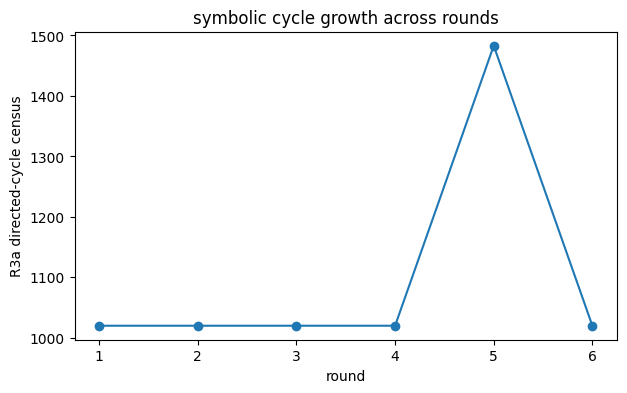

In [5]:
counts = [r.get("graph_cycle_count") for r in TOPO
          if r.get("graph_cycle_count") is not None]
rounds = [r["round_id"] for r in TOPO
          if r.get("graph_cycle_count") is not None]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, counts, marker="o")
ax.set_xlabel("round"); ax.set_ylabel("R3a directed-cycle census")
ax.set_title("symbolic cycle growth across rounds")
save_figure(fig, "nb6_r3a_census"); plt.show()

## R3b panel (secondary, honest reading)

The 4-cycle hand value anchors the filtration: edge distance 0.5 is born at 0.5 and dies at 1.0 (K4 completion) - persistence 0.5.

In [6]:
try:
    h1, meta = rips_h1_persistence(graph)
    persistence = h1[:, 1] - h1[:, 0]
    persistent = persistence[persistence > 0.1]
    print(f"R3b persistent H1 classes (persistence > 0.1): {len(persistent)}")
    print("READING: a geometric indicator of graph reorganization - "
          "R3b NEVER feeds the veto.")
except NotImplementedError:
    print("persistence engine pending (Fase 1-V2)")

R3b persistent H1 classes (persistence > 0.1): 1745
READING: a geometric indicator of graph reorganization - R3b NEVER feeds the veto.


## Cross with the NS quarantine

Do the directed cycles capture taxonomic contradictions that the pairwise detection quarantined, or do they see NEW damage?

In [7]:
quarantine_path = REPO / "triplets" / "quarantine.jsonl"
quarantined = load_jsonl(quarantine_path)
print(f"quarantined docs (NS pairwise detection): {len(quarantined)}")
cycle_entities = {e for c in cycles for e in c["path"]}
print(f"entities inside R3a cycles: {len(cycle_entities)}")
print("crossing the two sets is a qualitative readout: the census sees "
      "graph-wide structure, the pair detector sees local conflicts")

quarantined docs (NS pairwise detection): 2
entities inside R3a cycles: 332
crossing the two sets is a qualitative readout: the census sees graph-wide structure, the pair detector sees local conflicts
